# Análisis de Resultados del Sistema Multiagente de Cócteles

Este notebook analiza los resultados de las pruebas realizadas al sistema multiagente de información de cócteles. Se analizarán:

1. **Comparación de estrategias** (usadas vs esperadas)
2. **Tiempos de respuesta** por estrategia
3. **Presencia de palabras clave** en las respuestas
4. **Distribución de tiempos** entre diferentes estrategias

Los análisis se visualizarán mediante:
- Gráficos de barras
- Gráficos de líneas
- Mapas de calor
- Diagramas de caja y bigotes

## 1. Importar bibliotecas necesarias

Primero importamos las bibliotecas que necesitaremos para el análisis y visualización de los datos.

In [1]:
# Importar bibliotecas para análisis de datos
import json
import os
import glob
import numpy as np
import pandas as pd
from collections import Counter

# Importar bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configurar estilo de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
colors = ["#2D6ECC", "#FFA556", "#9C55F6", "#56BF7C", "#EA5C5C"]

# Configurar visualización en el notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 2. Cargar y procesar los datos de los tests

A continuación, cargaremos los archivos JSON de resultados de pruebas y los procesaremos para su análisis.

In [2]:
# Función auxiliar para inspeccionar los archivos JSON de resultados
def inspect_results_structure(all_results):
    """
    Inspecciona la estructura de los archivos de resultados para depuración
    """
    print(f"Total de archivos de resultados: {len(all_results)}")
    
    for file_name, data in all_results.items():
        print(f"\nArchivo: {file_name}")
        
        if isinstance(data, dict):
            print(f"- Tipo: Diccionario con {len(data)} claves")
            # Mostrar las claves principales
            print(f"- Claves principales: {list(data.keys())}")
            
            # Para cada tipo de test, mostrar cuántos hay
            for key, value in data.items():
                if isinstance(value, list):
                    # Ver si los tests tienen errores o respuestas
                    has_response = any('response' in item for item in value if isinstance(item, dict))
                    has_error = any('error' in item for item in value if isinstance(item, dict))
                    has_raw_output = any('raw_output' in item for item in value if isinstance(item, dict))
                    
                    print(f"  - {key}: {len(value)} tests (response: {has_response}, error: {has_error}, raw_output: {has_raw_output})")
                    
                    # Mostrar estructura del primer test como ejemplo
                    if value and isinstance(value[0], dict):
                        print(f"    Campos del primer test: {list(value[0].keys())}")
                        
                        # Mostrar estructura de test_case si existe
                        if 'test_case' in value[0] and isinstance(value[0]['test_case'], dict):
                            print(f"    Campos de test_case: {list(value[0]['test_case'].keys())}")
        else:
            print(f"- Tipo: {type(data)} (no es un diccionario)")

# Inspeccionar la estructura de los resultados
if 'all_test_results' in locals() and all_test_results:
    inspect_results_structure(all_test_results)
else:
    print("No hay resultados para inspeccionar")

No hay resultados para inspeccionar


In [3]:
# Definir función para cargar los archivos JSON de resultados
def load_test_results(results_dir='../results'):
    """
    Carga todos los archivos de resultados de tests del directorio especificado
    """
    # Ajustar la ruta para apuntar a tests/results
    json_files = glob.glob(os.path.join(results_dir, 'test_results_*.json'))
    
    # Si no se encuentran archivos, intentar con ruta alternativa
    if not json_files:
        alternative_path = './results'
        json_files = glob.glob(os.path.join(alternative_path, 'test_results_*.json'))
        
    # Si aún no se encuentran, probar con la ruta absoluta
    if not json_files:
        absolute_path = '/home/noel/Disco D/3er Anno/2do semestre/SRI/ia-sri-sim/tests/results'
        json_files = glob.glob(os.path.join(absolute_path, 'test_results_*.json'))
    
    print(f"Encontrados {len(json_files)} archivos de resultados de tests")
    
    all_results = {}
    
    # Cargar cada archivo
    for file_path in json_files:
        file_name = os.path.basename(file_path)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                all_results[file_name] = data
                print(f"Cargado archivo: {file_name}")
        except Exception as e:
            print(f"Error al cargar {file_name}: {e}")
    
    return all_results

# Cargar todos los resultados disponibles
all_test_results = load_test_results()

Encontrados 3 archivos de resultados de tests
Cargado archivo: test_results_20250622_183606.json
Cargado archivo: test_results_20250622_183541.json
Cargado archivo: test_results_20250622_165543.json


In [4]:
# Procesar los resultados para análisis
def process_test_data(all_results):
    """
    Procesa los datos de resultados de tests y los convierte en un DataFrame
    para facilitar análisis y visualizaciones
    """
    all_tests = []
    
    # Procesar cada archivo de resultados
    for file_name, data in all_results.items():
        # Determinar el formato del archivo
        if isinstance(data, dict) and 'results' in data:
            # Formato con metadata y lista de resultados
            results = data['results']
            for test in results:
                test['source_file'] = file_name
                all_tests.append(test)
        elif isinstance(data, dict) and all(isinstance(data[k], list) for k in data):
            # Formato con resultados agrupados por tipo de test
            for test_type, tests in data.items():
                for test in tests:
                    test['test_type'] = test_type
                    test['source_file'] = file_name
                    all_tests.append(test)
    
    # Convertir a DataFrame
    if not all_tests:
        print("No se encontraron datos de tests en el formato esperado")
        return pd.DataFrame()
    
    df = pd.json_normalize(all_tests)
    
    # Extraer campos de test_case para facilitar el análisis
    if 'test_case.expected_strategy' in df.columns:
        df['expected_strategy'] = df['test_case.expected_strategy']
    
    if 'test_case.expected_keywords' in df.columns:
        df['expected_keywords'] = df['test_case.expected_keywords']
    
    if 'test_case.expected_response_elements' in df.columns:
        df['expected_response_elements'] = df['test_case.expected_response_elements']
    
    if 'test_case.query' in df.columns:
        df['query'] = df['test_case.query']
    
    # Normalizar nombres de estrategias
    strategy_mapping = {
        'ontology': 'ontology',
        'embedding': 'embedding', 
        'dynamic_crawler': 'crawler',
        'crawler': 'crawler',
        'unknown': 'unknown'
    }
    
    if 'detected_strategy' in df.columns:
        df['detected_strategy'] = df['detected_strategy'].map(lambda x: strategy_mapping.get(x, x))
    
    if 'expected_strategy' in df.columns:
        df['expected_strategy'] = df['expected_strategy'].map(lambda x: strategy_mapping.get(x, x))
    
    # Extraer tiempo de respuesta si está disponible
    if 'response_time' in df.columns:
        df['response_time_sec'] = df['response_time']
    
    # Extraer success status
    if 'success' in df.columns:
        df['success'] = df['success'].astype(bool)
    
    # Manejar casos de error (cuando no hay una respuesta)
    if 'error' in df.columns and 'response' not in df.columns:
        df['response'] = ""  # Inicializar con cadena vacía
    
    # Si hay raw_output pero no response o la response está vacía, extraer la respuesta del raw_output
    if 'raw_output' in df.columns:
        # Función para extraer respuesta de raw_output
        def extract_response(raw_output):
            if not isinstance(raw_output, str):
                return ""
            
            # Buscar el inicio de los resultados
            if "--------------------------------------------------\n" in raw_output and "\n--------------------------------------------------\n" in raw_output:
                # Extraer el contenido entre las líneas de separación
                start_marker = "--------------------------------------------------\n"
                end_marker = "\n--------------------------------------------------\n"
                start_idx = raw_output.find(start_marker)
                if start_idx != -1:
                    start_idx += len(start_marker)
                    end_idx = raw_output.find(end_marker, start_idx)
                    if end_idx != -1:
                        return raw_output[start_idx:end_idx].strip()
            
            # Otro formato posible
            result_marker = "QUERY RESULTS:"
            if result_marker in raw_output:
                result_section = raw_output.split(result_marker)[1]
                # Quitar líneas de separación
                result_section = result_section.replace("-" * 40, "")
                return result_section.strip()
            
            return ""
        
        # Aplicar la extracción
        df['response'] = df.apply(lambda row: 
                                 row['response'] if pd.notnull(row.get('response', '')) and row.get('response', '') 
                                 else extract_response(row.get('raw_output', '')), 
                                 axis=1)
        
        # Verificar si hubo éxito en la extracción
        response_count = df['response'].apply(lambda x: len(str(x).strip()) > 0).sum()
        print(f"\nSe extrajeron {response_count} respuestas de {len(df)} resultados ({response_count/len(df)*100:.1f}%)")
        
        if response_count == 0:
            print("\nAdvertencia: No se pudo extraer ninguna respuesta del raw_output. Revisando ejemplos...")
            # Mostrar ejemplos de raw_output para depuración
            for i, row in df.sample(min(3, len(df))).iterrows():
                raw = row.get('raw_output', '')
                if isinstance(raw, str):
                    print(f"\nEjemplo de raw_output (primeros 500 caracteres):\n{raw[:500]}...")
    
    return df

# Procesar datos y crear DataFrame
test_df = process_test_data(all_test_results)

# Mostrar información básica
if not test_df.empty:
    print(f"\nDatos procesados: {len(test_df)} tests")
    print("\nDistribución de estrategias esperadas:")
    if 'expected_strategy' in test_df.columns:
        print(test_df['expected_strategy'].value_counts())
    
    print("\nColumnas disponibles:")
    print(test_df.columns.tolist())
else:
    print("No se encontraron datos para analizar")


Se extrajeron 27 respuestas de 27 resultados (100.0%)

Datos procesados: 27 tests

Distribución de estrategias esperadas:
expected_strategy
ontology     11
embedding    11
crawler       5
Name: count, dtype: int64

Columnas disponibles:
['query', 'response', 'detected_strategy', 'response_time', 'success', 'raw_output', 'test_type', 'source_file', 'test_case.query', 'test_case.expected_strategy', 'test_case.expected_keywords', 'test_case.expected_sections', 'test_case.expected_response_elements', 'error', 'expected_strategy', 'expected_keywords', 'expected_response_elements', 'response_time_sec']


## 3. Análisis de estrategias: usadas vs esperadas

Vamos a analizar la precisión del sistema para seleccionar la estrategia correcta, comparando la estrategia detectada con la estrategia esperada para cada test.

In [5]:
# Función para calcular matriz de confusión de estrategias
def calculate_strategy_matrix(df):
    """Calcula una matriz de confusión para las estrategias detectadas vs esperadas"""
    if 'detected_strategy' not in df.columns or 'expected_strategy' not in df.columns:
        print("No hay datos suficientes para analizar estrategias")
        return None, None, None
    
    # Filtrar filas con datos válidos
    valid_df = df.dropna(subset=['detected_strategy', 'expected_strategy'])
    
    # Obtener todas las estrategias únicas
    all_strategies = sorted(set(valid_df['detected_strategy'].unique()) | 
                           set(valid_df['expected_strategy'].unique()))
    
    # Crear matriz de confusión
    confusion_matrix = pd.DataFrame(0, 
                                   index=all_strategies,
                                   columns=all_strategies)
    
    # Llenar la matriz
    for _, row in valid_df.iterrows():
        detected = row['detected_strategy']
        expected = row['expected_strategy']
        confusion_matrix.at[detected, expected] += 1
    
    # Calcular precisión por estrategia
    strategy_accuracy = {}
    for strategy in all_strategies:
        # Total de tests donde se esperaba esta estrategia
        total = confusion_matrix[strategy].sum()
        # Tests donde la estrategia detectada coincide con la esperada
        correct = confusion_matrix.at[strategy, strategy] if strategy in confusion_matrix.index else 0
        accuracy = correct / total if total > 0 else 0
        strategy_accuracy[strategy] = {
            'total': total,
            'correct': correct,
            'accuracy': accuracy
        }
    
    # Precisión global
    total_tests = len(valid_df)
    correct_tests = sum(1 for _, row in valid_df.iterrows() 
                      if row['detected_strategy'] == row['expected_strategy'])
    overall_accuracy = correct_tests / total_tests if total_tests > 0 else 0
    
    return confusion_matrix, strategy_accuracy, overall_accuracy

# Calcular matriz de confusión y precisión
if not test_df.empty:
    confusion_matrix, strategy_accuracy, overall_accuracy = calculate_strategy_matrix(test_df)
    
    if confusion_matrix is not None:
        print(f"Matriz de confusión de estrategias:")
        print(confusion_matrix)
        
        print(f"\nPrecisión por estrategia:")
        for strategy, stats in strategy_accuracy.items():
            print(f"{strategy}: {stats['accuracy']:.2%} ({stats['correct']}/{stats['total']})")
        
        print(f"\nPrecisión global: {overall_accuracy:.2%}")
    else:
        print("No se pudieron calcular estadísticas de estrategias")

Matriz de confusión de estrategias:
           crawler  embedding  ontology
crawler          5          0         1
embedding        0         11         0
ontology         0          0         8

Precisión por estrategia:
crawler: 100.00% (5/5)
embedding: 100.00% (11/11)
ontology: 88.89% (8/9)

Precisión global: 96.00%


<Figure size 1400x1000 with 0 Axes>

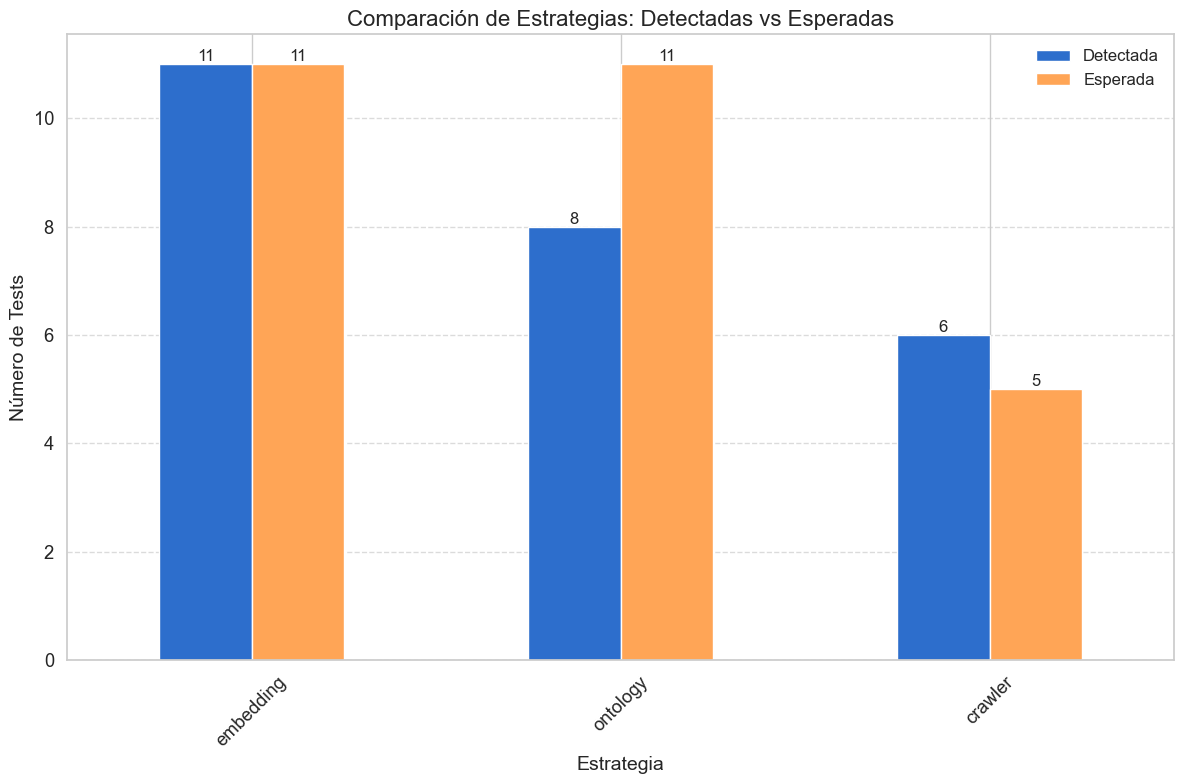

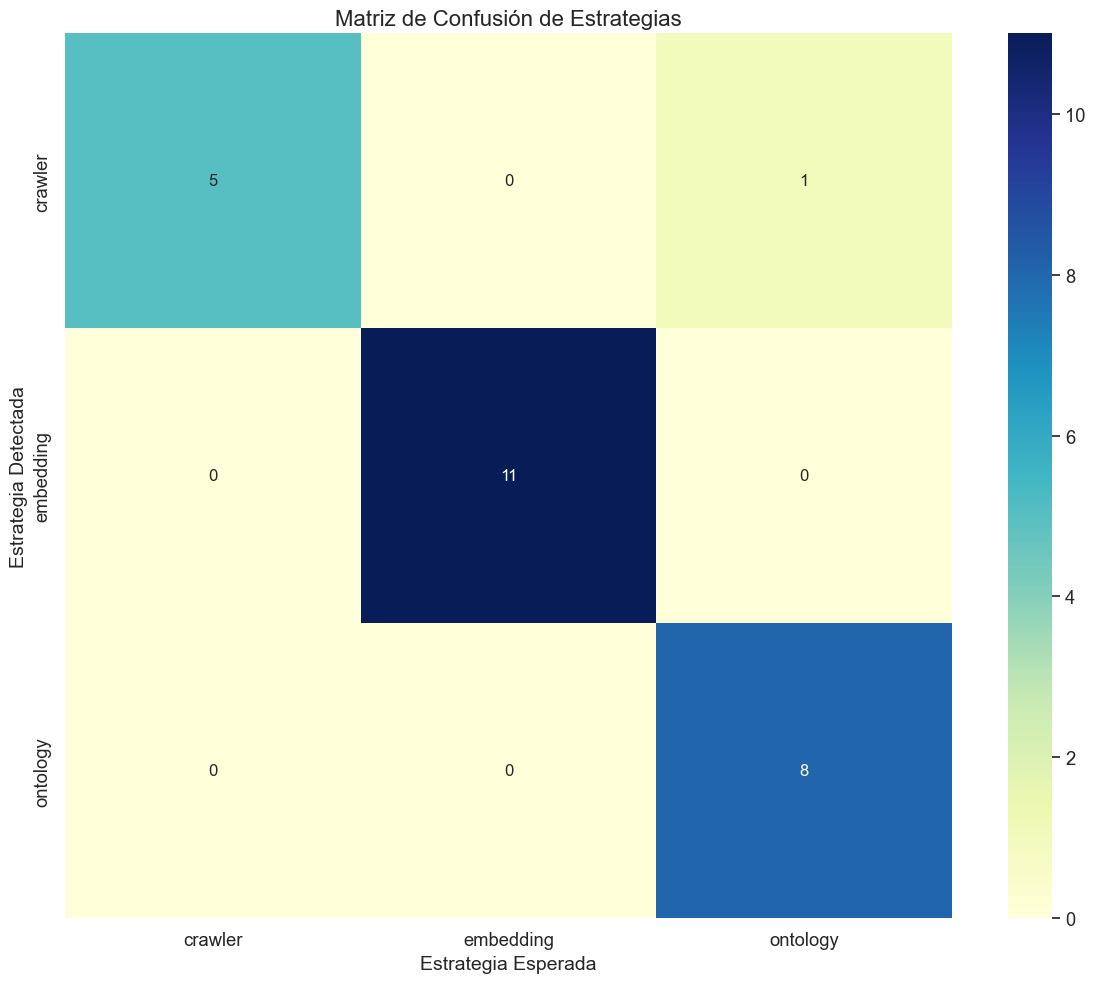

In [6]:
# Visualizar comparación de estrategias con gráfico de barras
if not test_df.empty and 'detected_strategy' in test_df.columns and 'expected_strategy' in test_df.columns:
    plt.figure(figsize=(14, 10))
    
    # Crear un DataFrame para la visualización
    strategy_counts = pd.DataFrame({
        'Detectada': test_df['detected_strategy'].value_counts(),
        'Esperada': test_df['expected_strategy'].value_counts()
    }).fillna(0).astype(int)
    
    # Ordenar por estrategias esperadas
    strategy_counts = strategy_counts.sort_values(by='Esperada', ascending=False)
    
    # Crear gráfico de barras agrupadas
    ax = strategy_counts.plot(kind='bar', color=[colors[0], colors[1]])
    plt.title('Comparación de Estrategias: Detectadas vs Esperadas', fontsize=16)
    plt.xlabel('Estrategia', fontsize=14)
    plt.ylabel('Número de Tests', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    
    # Añadir etiquetas de valores a las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=12)
        
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Visualizar matriz de confusión como un heatmap
    if confusion_matrix is not None:
        plt.figure(figsize=(12, 10))
        
        # Crear un mapa de calor para la matriz de confusión
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlGnBu',
                   xticklabels=confusion_matrix.columns, 
                   yticklabels=confusion_matrix.index)
        
        plt.title('Matriz de Confusión de Estrategias', fontsize=16)
        plt.xlabel('Estrategia Esperada', fontsize=14)
        plt.ylabel('Estrategia Detectada', fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos suficientes para visualizar estrategias")

## 4. Análisis de tiempos de respuesta

A continuación, analizaremos los tiempos de respuesta para cada test y cada estrategia.

In [7]:
# Analizar tiempos de respuesta por estrategia
def analyze_response_times(df):
    """Analiza los tiempos de respuesta agrupados por estrategia"""
    if 'response_time_sec' not in df.columns and 'response_time' not in df.columns:
        print("No hay datos de tiempo de respuesta disponibles")
        return None
    
    # Usar la columna de tiempo correcta
    time_col = 'response_time_sec' if 'response_time_sec' in df.columns else 'response_time'
    
    # Filtrar filas con datos válidos
    valid_df = df.dropna(subset=[time_col, 'detected_strategy'])
    
    # Calcular estadísticas por estrategia
    stats = valid_df.groupby('detected_strategy')[time_col].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('median', 'median'),
        ('min', 'min'),
        ('max', 'max'),
        ('std', 'std')
    ]).round(2)
    
    return stats

# Calcular estadísticas de tiempo de respuesta
if not test_df.empty:
    response_time_stats = analyze_response_times(test_df)
    
    if response_time_stats is not None:
        print("Estadísticas de tiempo de respuesta por estrategia (segundos):")
        print(response_time_stats)
    else:
        print("No se pudieron calcular estadísticas de tiempo de respuesta")

Estadísticas de tiempo de respuesta por estrategia (segundos):
                   count   mean  median   min   max   std
detected_strategy                                        
crawler                6  19.17    16.5  12.0  36.0  8.89
embedding             11  15.73    13.0  12.0  23.0  4.47
ontology               8  13.75    14.0  11.0  17.0  2.05


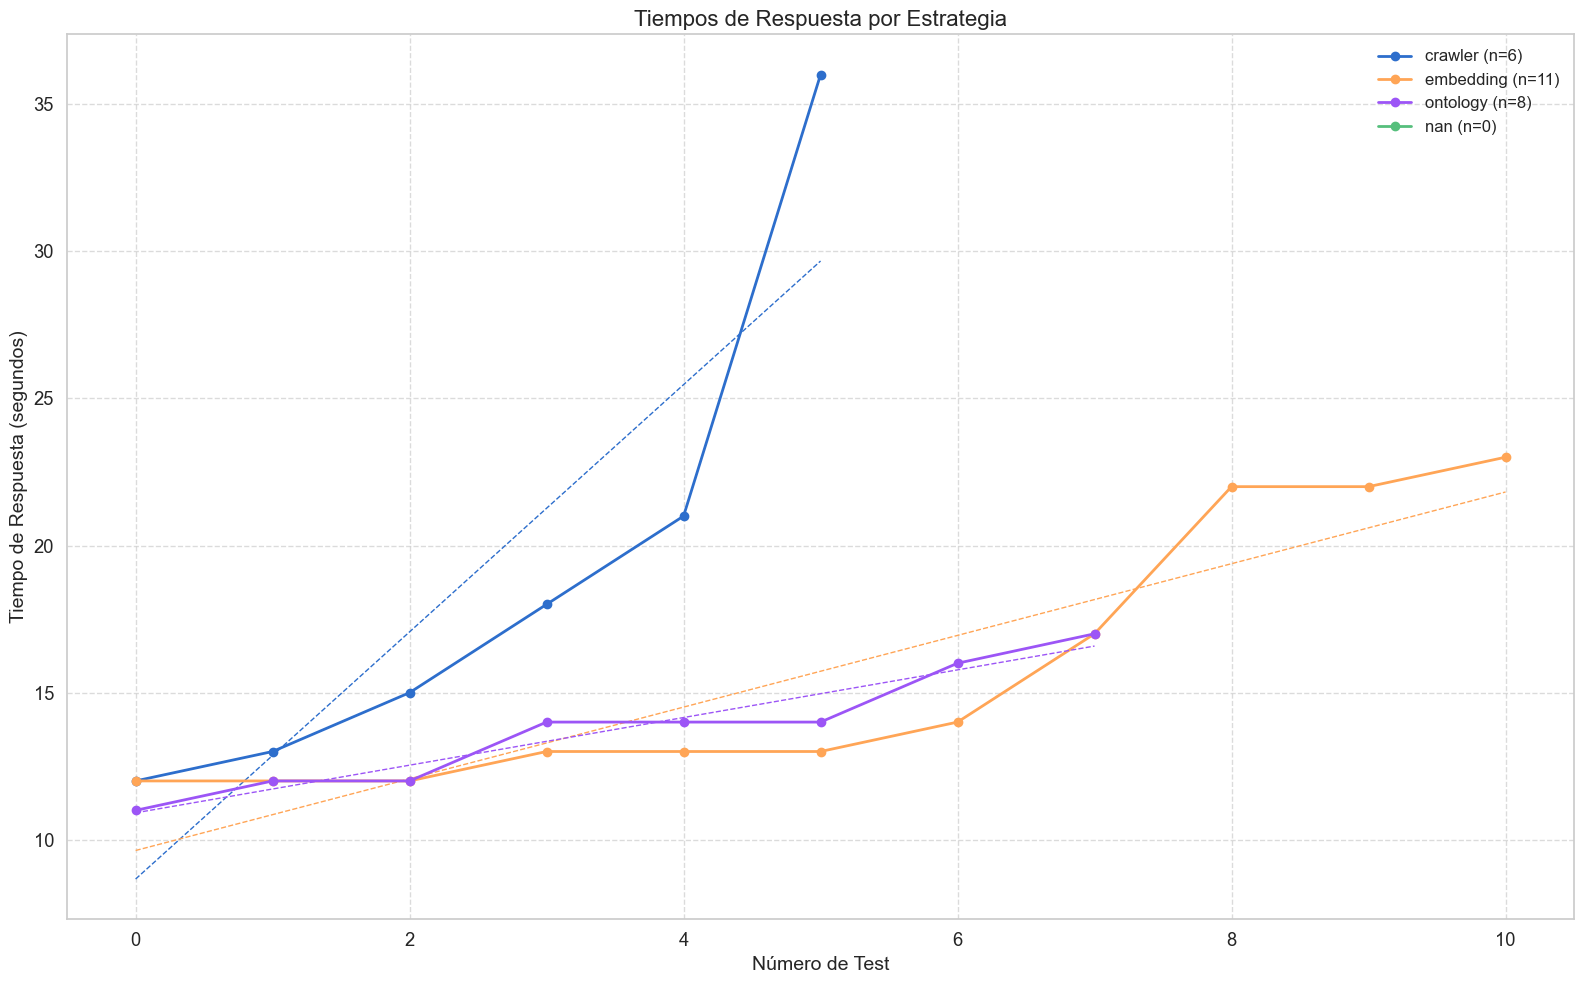

In [8]:
# Visualizar tiempos de respuesta con un gráfico de líneas
if not test_df.empty:
    # Determinar la columna de tiempo correcta
    time_col = 'response_time_sec' if 'response_time_sec' in test_df.columns else 'response_time'
    
    if time_col in test_df.columns:
        # Ordenar datos por estrategia y luego por tiempo
        sorted_df = test_df.sort_values(by=['detected_strategy', time_col])
        
        plt.figure(figsize=(16, 10))
        
        # Crear gráfico de líneas para cada estrategia
        strategies = sorted_df['detected_strategy'].unique()
        
        for i, strategy in enumerate(strategies):
            strategy_data = sorted_df[sorted_df['detected_strategy'] == strategy]
            # Crear índices para el eje x
            indices = range(len(strategy_data))
            
            plt.plot(indices, strategy_data[time_col], 
                    marker='o', 
                    label=f'{strategy} (n={len(strategy_data)})',
                    linewidth=2,
                    color=colors[i % len(colors)])
            
            # Añadir línea de tendencia
            if len(strategy_data) > 2:
                z = np.polyfit(indices, strategy_data[time_col], 1)
                p = np.poly1d(z)
                plt.plot(indices, p(indices), 
                        linestyle='--', 
                        linewidth=1, 
                        color=colors[i % len(colors)])
        
        plt.title('Tiempos de Respuesta por Estrategia', fontsize=16)
        plt.xlabel('Número de Test', fontsize=14)
        plt.ylabel('Tiempo de Respuesta (segundos)', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos de tiempo de respuesta")

/tmp/ipykernel_3410/747341398.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='detected_strategy', y=time_col,
/tmp/ipykernel_3410/747341398.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


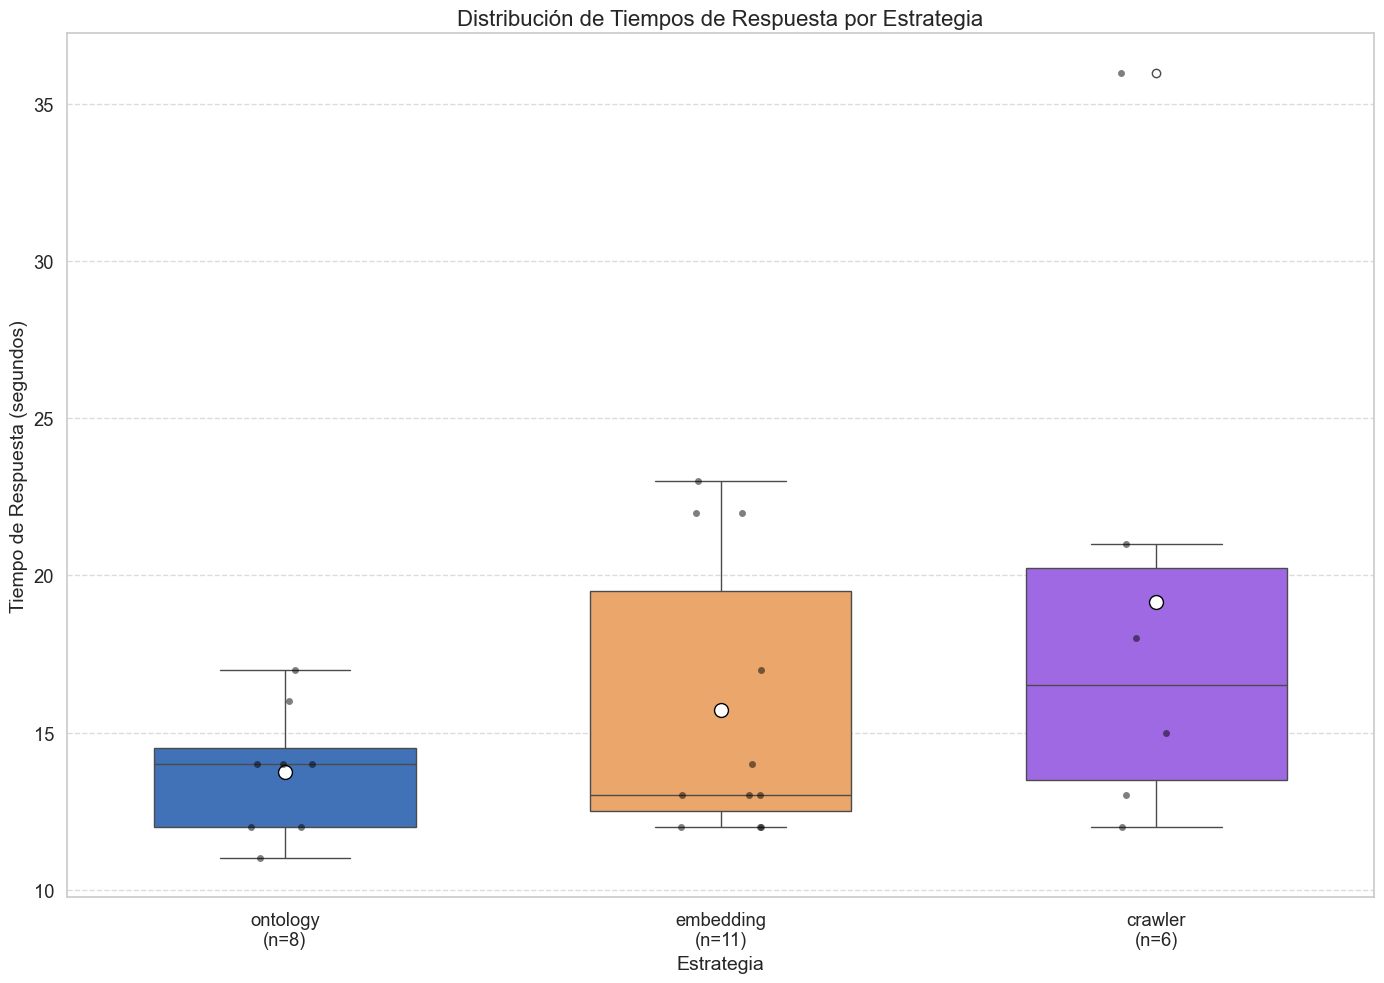

In [9]:
# Visualizar distribución de tiempos con diagrama de caja y bigotes
if not test_df.empty:
    # Determinar la columna de tiempo correcta
    time_col = 'response_time_sec' if 'response_time_sec' in test_df.columns else 'response_time'
    
    if time_col in test_df.columns and 'detected_strategy' in test_df.columns:
        # Eliminar filas con estrategias NaN para el análisis
        valid_df = test_df.dropna(subset=['detected_strategy'])
        
        if len(valid_df) > 0:
            plt.figure(figsize=(14, 10))
            
            # Crear boxplot
            ax = sns.boxplot(x='detected_strategy', y=time_col, 
                            data=valid_df,
                            palette=colors[:len(valid_df['detected_strategy'].unique())],
                            width=0.6,
                            showmeans=True,
                            meanprops={"marker":"o", 
                                      "markerfacecolor":"white", 
                                      "markeredgecolor":"black",
                                      "markersize":"10"})
            
            # Añadir puntos individuales
            sns.stripplot(x='detected_strategy', y=time_col, 
                         data=valid_df,
                         jitter=True,
                         size=5,
                         alpha=0.5,
                         color='black',
                         ax=ax)
            
            plt.title('Distribución de Tiempos de Respuesta por Estrategia', fontsize=16)
            plt.xlabel('Estrategia', fontsize=14)
            plt.ylabel('Tiempo de Respuesta (segundos)', fontsize=14)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            
            # Añadir etiquetas con número de tests por estrategia
            strategy_counts = valid_df['detected_strategy'].value_counts()
            
            # Obtener las categorías únicas (estrategias) que aparecen en el eje x
            unique_strategies = valid_df['detected_strategy'].unique()
            
            # Crear etiquetas para cada estrategia
            labels = []
            for strat in unique_strategies:
                count = strategy_counts.get(strat, 0)
                labels.append(f"{strat}\n(n={count})")
            
            # Establecer las etiquetas
            ax.set_xticklabels(labels)
            
            plt.tight_layout()
            plt.show()
        else:
            print("No hay datos válidos con estrategias definidas para visualizar")
    else:
        print("No hay datos suficientes para visualizar la distribución de tiempos")

## 5. Análisis de palabras clave en las respuestas

A continuación, analizaremos la presencia de palabras clave esperadas en las respuestas generadas por el sistema.

In [10]:
# Función para analizar presencia de palabras clave en las respuestas
def analyze_keywords_in_responses(df):
    """
    Analiza la presencia de palabras clave esperadas en las respuestas generadas
    Devuelve una matriz de presencia/ausencia y un resumen de precisión
    """
    print("Analizando palabras clave en las respuestas...")
    
    # Verificar que tenemos los datos necesarios
    required_cols = ['response']
    keyword_cols = ['expected_keywords', 'test_case.expected_keywords', 'expected_response_elements', 'test_case.expected_response_elements']
    
    # Mostrar columnas disponibles para debug
    print(f"Columnas disponibles en el DataFrame: {df.columns.tolist()}")
    
    # Verificar qué columnas de palabras clave están disponibles
    available_keyword_cols = [col for col in keyword_cols if col in df.columns]
    print(f"Columnas de palabras clave disponibles: {available_keyword_cols}")
    
    if not available_keyword_cols or 'response' not in df.columns:
        print("No hay datos suficientes para analizar palabras clave")
        return None, None
    
    # Determinar qué columna de palabras clave usar (priorizar expected_keywords sobre expected_response_elements)
    keyword_priority_order = ['expected_keywords', 'test_case.expected_keywords', 
                              'expected_response_elements', 'test_case.expected_response_elements']
    keyword_col = next((col for col in keyword_priority_order if col in df.columns), None)
    
    print(f"Usando columna de palabras clave: {keyword_col}")
    
    # Verificar contenido de respuestas
    empty_responses = df['response'].isnull().sum() + df['response'].apply(lambda x: str(x).strip() == '').sum()
    print(f"Respuestas vacías: {empty_responses} de {len(df)} ({empty_responses/len(df)*100:.1f}%)")
    
    # Si hay muchas respuestas vacías, intentar extraer las respuestas de raw_output de nuevo
    if empty_responses > 0 and 'raw_output' in df.columns:
        print("Intentando extraer respuestas adicionales del raw_output...")
        
        # Mostrar ejemplos de raw_output para entender su estructura
        sample_raw = df[df['response'].isnull() | (df['response'] == '')].sample(min(3, empty_responses))
        for i, (idx, row) in enumerate(sample_raw.iterrows()):
            raw = row.get('raw_output', '')
            if isinstance(raw, str) and "Results for:" in raw and "--------------------------------------------------" in raw:
                print(f"\nEjemplo {i+1} de raw_output con posible respuesta detectada:")
                start_idx = raw.find("Results for:")
                end_idx = min(start_idx + 500, len(raw))
                print(raw[start_idx:end_idx])
    
    # Filtrar filas con datos válidos
    valid_df = df.dropna(subset=[keyword_col, 'response'])
    # Eliminar también las filas con respuestas vacías
    valid_df = valid_df[valid_df['response'].apply(lambda x: str(x).strip() != '')]
    print(f"Filas con datos válidos: {len(valid_df)} de {len(df)}")
    
    # Debug: Ver contenido de palabras clave en algunas filas de muestra
    if not valid_df.empty:
        print("\nMuestra de palabras clave esperadas para algunos tests:")
        for i, (idx, row) in enumerate(valid_df.sample(min(3, len(valid_df))).iterrows()):
            print(f"Test {i+1}: {row[keyword_col]}")
            # Mostrar también las primeras líneas de la respuesta
            resp = row['response']
            print(f"Primeras 100 caracteres de la respuesta: {resp[:100]}...\n")
    
    if len(valid_df) == 0:
        print("No hay datos válidos para analizar palabras clave")
        return None, None
    
    # Preparar matriz de presencia/ausencia de palabras clave
    all_keywords = set()
    for keywords in valid_df[keyword_col]:
        if isinstance(keywords, list):
            all_keywords.update(keywords)
        elif isinstance(keywords, str):
            # Por si las palabras clave se almacenaron como una cadena en lugar de lista
            all_keywords.add(keywords)
    
    all_keywords = sorted(all_keywords)
    print(f"Total de palabras clave únicas encontradas: {len(all_keywords)}")
    print(f"Ejemplos de palabras clave: {', '.join(list(all_keywords)[:10])}")
    
    keyword_matrix = pd.DataFrame(0, index=valid_df.index, columns=all_keywords)
    
    # Calcular presencia/ausencia con depuración
    keyword_hits = {k: 0 for k in all_keywords}
    total_responses_with_keywords = 0
    response_lengths = []
    
    for idx, row in valid_df.iterrows():
        response = str(row['response']).lower()
        response_lengths.append(len(response))
        
        if not response:
            print(f"Respuesta vacía para test {idx}")
            continue
            
        # Obtener palabras clave esperadas para este test
        expected_keywords = row[keyword_col] if isinstance(row[keyword_col], list) else []
        keywords_found = False
        
        # Comprobar presencia de cada palabra clave
        for keyword in all_keywords:
            if not isinstance(keyword, str):
                continue
                
            if keyword.lower() in response:
                keyword_matrix.at[idx, keyword] = 1
                keyword_hits[keyword] += 1
                keywords_found = True
                
        if keywords_found:
            total_responses_with_keywords += 1
    
    print(f"\nEstadísticas de respuestas:")
    print(f"- Promedio de longitud de respuesta: {sum(response_lengths)/len(response_lengths) if response_lengths else 0:.1f} caracteres")
    print(f"- Respuestas con al menos una palabra clave: {total_responses_with_keywords} de {len(valid_df)} ({total_responses_with_keywords/len(valid_df)*100 if len(valid_df) > 0 else 0:.1f}%)")
    
    # Palabras clave más encontradas
    top_keywords = sorted([(k, v) for k, v in keyword_hits.items() if v > 0], 
                         key=lambda x: x[1], reverse=True)[:10]
    
    if top_keywords:
        print("\nPalabras clave más encontradas:")
        for keyword, count in top_keywords:
            print(f"- {keyword}: {count} veces")
    else:
        print("\nNo se encontró ninguna palabra clave en las respuestas.")
    
    # Calcular métricas de precisión
    keyword_scores = {}
    for idx, row in valid_df.iterrows():
        expected_keywords = row[keyword_col] if isinstance(row[keyword_col], list) else []
        if not expected_keywords:
            continue
            
        found_keywords = []
        for keyword in expected_keywords:
            if keyword in all_keywords and keyword_matrix.at[idx, keyword] == 1:
                found_keywords.append(keyword)
        
        precision = len(found_keywords) / len(expected_keywords) if expected_keywords else 0
        
        # Guardar métricas
        query = row['query'] if 'query' in row else f"Test {idx}"
        keyword_scores[query] = {
            'expected': expected_keywords,
            'found': found_keywords,
            'total_expected': len(expected_keywords),
            'total_found': len(found_keywords),
            'precision': precision
        }
    
    return keyword_matrix, keyword_scores

# Analizar presencia de palabras clave en respuestas
if not test_df.empty:
    keyword_matrix, keyword_scores = analyze_keywords_in_responses(test_df)
    
    if keyword_matrix is not None and keyword_scores is not None:
        # Resumen de precisión global
        total_expected = sum(score['total_expected'] for score in keyword_scores.values())
        total_found = sum(score['total_found'] for score in keyword_scores.values())
        overall_precision = total_found / total_expected if total_expected > 0 else 0
        
        print(f"Análisis de palabras clave en respuestas:")
        print(f"- Palabras clave esperadas en total: {total_expected}")
        print(f"- Palabras clave encontradas en total: {total_found}")
        print(f"- Precisión global: {overall_precision:.2%}")
        
        if total_found == 0:
            print("\nATENCIÓN: No se encontró ninguna palabra clave. Esto puede deberse a:")
            print("1. Las respuestas están vacías o con errores")
            print("2. Las palabras clave esperadas no coinciden exactamente con el texto de las respuestas")
            print("3. Problemas con acentos o formato de texto")
        
        # Top 5 tests con mayor precisión (si hay alguno con palabras clave)
        if total_found > 0:
            top_tests = sorted(keyword_scores.items(), 
                              key=lambda x: x[1]['precision'], 
                              reverse=True)[:5]
            
            print("\nTop 5 tests con mayor precisión de palabras clave:")
            for query, score in top_tests:
                print(f"- {query[:50]}... : {score['precision']:.2%} ({score['total_found']}/{score['total_expected']})")
            
            # Top 5 tests con menor precisión
            bottom_tests = sorted(keyword_scores.items(), 
                                 key=lambda x: x[1]['precision'])[:5]
            
            print("\nTop 5 tests con menor precisión de palabras clave:")
            for query, score in bottom_tests:
                print(f"- {query[:50]}... : {score['precision']:.2%} ({score['total_found']}/{score['total_expected']})")
    else:
        print("No se pudieron analizar palabras clave en las respuestas")

Analizando palabras clave en las respuestas...
Columnas disponibles en el DataFrame: ['query', 'response', 'detected_strategy', 'response_time', 'success', 'raw_output', 'test_type', 'source_file', 'test_case.query', 'test_case.expected_strategy', 'test_case.expected_keywords', 'test_case.expected_sections', 'test_case.expected_response_elements', 'error', 'expected_strategy', 'expected_keywords', 'expected_response_elements', 'response_time_sec']
Columnas de palabras clave disponibles: ['expected_keywords', 'test_case.expected_keywords', 'expected_response_elements', 'test_case.expected_response_elements']
Usando columna de palabras clave: expected_keywords
Respuestas vacías: 0 de 27 (0.0%)
Filas con datos válidos: 27 de 27

Muestra de palabras clave esperadas para algunos tests:
Test 1: ['vodka', 'café', 'espresso', 'kahlua', 'azúcar', 'licor de café']
Primeras 100 caracteres de la respuesta: Un Espresso Martini es un cóctel delicioso y energizante. Según la información disponible, l

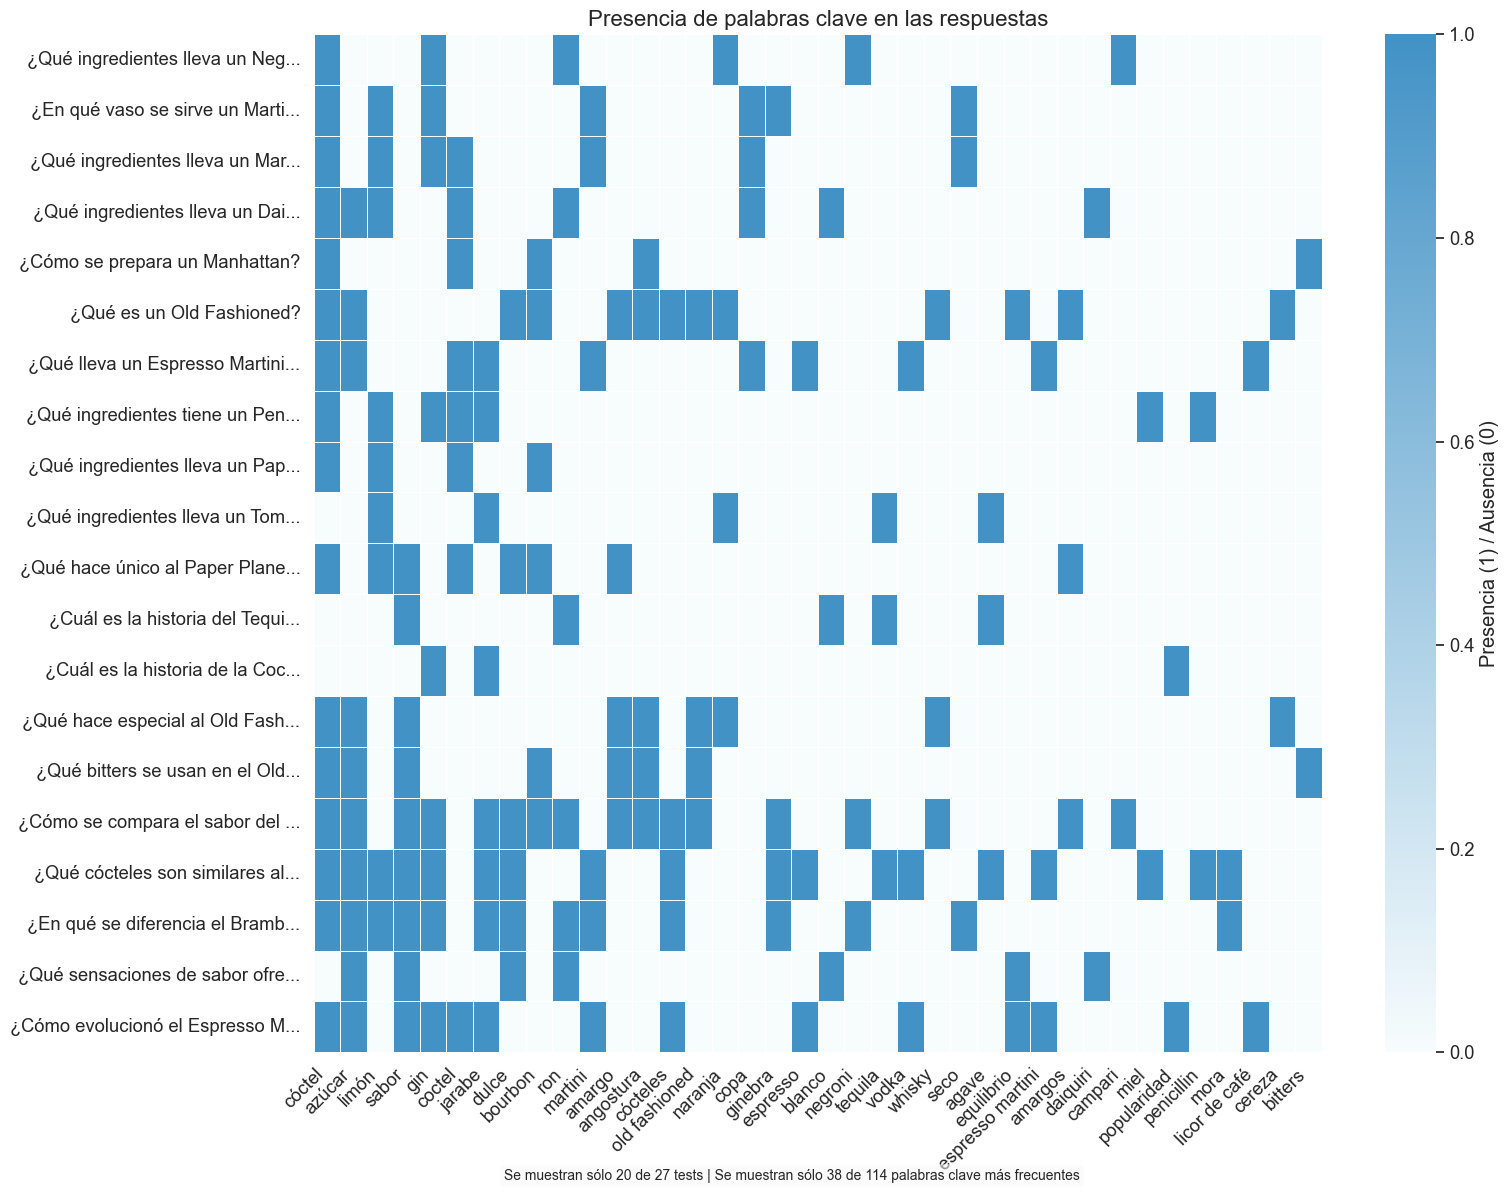

In [11]:
# Visualizar mapa de calor de presencia de palabras clave
if not test_df.empty and keyword_matrix is not None:
    # Verificar si hay datos en la matriz de palabras clave
    if keyword_matrix.empty or keyword_matrix.sum().sum() == 0:
        print("No hay datos suficientes para visualizar un mapa de calor:")
        print(f"- Shape de la matriz: {keyword_matrix.shape}")
        print(f"- Suma total de elementos: {keyword_matrix.sum().sum()}")
        print("No se creará la visualización de mapa de calor.")
    else:
        try:
            # Preparar datos para visualización
            # Limitar a un número manejable de tests para el mapa de calor si hay muchos
            max_tests = 20
            if len(keyword_matrix) > max_tests:
                # Seleccionar una muestra representativa
                selected_indices = list(keyword_matrix.index)[:max_tests]
                vis_matrix = keyword_matrix.loc[selected_indices]
                truncated = True
            else:
                vis_matrix = keyword_matrix
                truncated = False
            
            # Limitar también el número de palabras clave si hay muchas
            max_keywords = 38  # Máximo número de palabras clave que se pueden mostrar claramente
            if vis_matrix.shape[1] > max_keywords:
                # Seleccionar las palabras clave más frecuentes
                keyword_freq = vis_matrix.sum().sort_values(ascending=False)
                top_keywords = keyword_freq.head(max_keywords).index.tolist()
                vis_matrix = vis_matrix[top_keywords]
                keywords_truncated = True
            else:
                keywords_truncated = False
            
            # Simplificar nombres de tests para el mapa de calor
            if 'query' in test_df.columns:
                test_labels = {}
                for idx in vis_matrix.index:
                    if idx in test_df.index:
                        query = test_df.loc[idx, 'query']
                        # Truncar consultas largas
                        test_labels[idx] = query[:30] + '...' if len(query) > 30 else query
                    else:
                        test_labels[idx] = f"Test {idx}"
            else:
                test_labels = {idx: f"Test {i+1}" for i, idx in enumerate(vis_matrix.index)}
            
            # Crear mapa de calor de palabras clave
            plt.figure(figsize=(16, 12))
            
            # Usar un mapa de colores personalizado
            cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#f7fcfd', '#4292c6'])
            
            # Crear heatmap
            ax = sns.heatmap(vis_matrix, 
                            cmap=cmap, 
                            cbar_kws={'label': 'Presencia (1) / Ausencia (0)'},
                            linewidths=0.5)
            
            # Configurar etiquetas
            if vis_matrix.shape[0] > 0:  # Solo si hay filas
                ax.set_yticklabels([test_labels[idx] for idx in vis_matrix.index], rotation=0)
            
            # Configurar etiquetas del eje X con rotación
            if vis_matrix.shape[1] > 0:  # Solo si hay columnas
                plt.xticks(np.arange(0.5, len(vis_matrix.columns)), vis_matrix.columns, rotation=45, ha='right')
            
            plt.title('Presencia de palabras clave en las respuestas', fontsize=16)
            plt.tight_layout()
            
            # Mostrar notas si se truncaron datos
            if truncated or keywords_truncated:
                note_text = []
                if truncated:
                    note_text.append(f"Se muestran sólo {max_tests} de {len(keyword_matrix)} tests")
                if keywords_truncated:
                    note_text.append(f"Se muestran sólo {max_keywords} de {keyword_matrix.shape[1]} palabras clave más frecuentes")
                
                # Añadir nota al gráfico
                plt.figtext(0.5, 0.01, ' | '.join(note_text), ha='center', fontsize=10, 
                           bbox=dict(facecolor='#f9f9f9', alpha=0.5, boxstyle='round'))
            
            plt.show()
        
        except Exception as e:
            print(f"Error al crear el mapa de calor: {str(e)}")
            print("Dimensiones de la matriz:", keyword_matrix.shape)
            print("Columnas disponibles:", keyword_matrix.columns.tolist() if not keyword_matrix.empty else "Ninguna")
else:
    print("No hay datos disponibles para visualizar el mapa de calor de palabras clave")

## 6. Análisis del uso del crawler dinámico

Finalmente, analizaremos el porcentaje de consultas que no necesitaron activar el crawler dinámico, lo que indica que la información local fue suficiente.

Análisis del uso del crawler dinámico:
- Total de tests: 27
- Tests que usaron crawler: 6 (22.2%)
- Tests que usaron información local: 21 (77.8%)

Consultas que podrían haber necesitado crawler pero se resolvieron localmente:
- Esperaban usar crawler: 5
- Resueltas con info local: 0
- Ahorro de llamadas al crawler: 0.0%


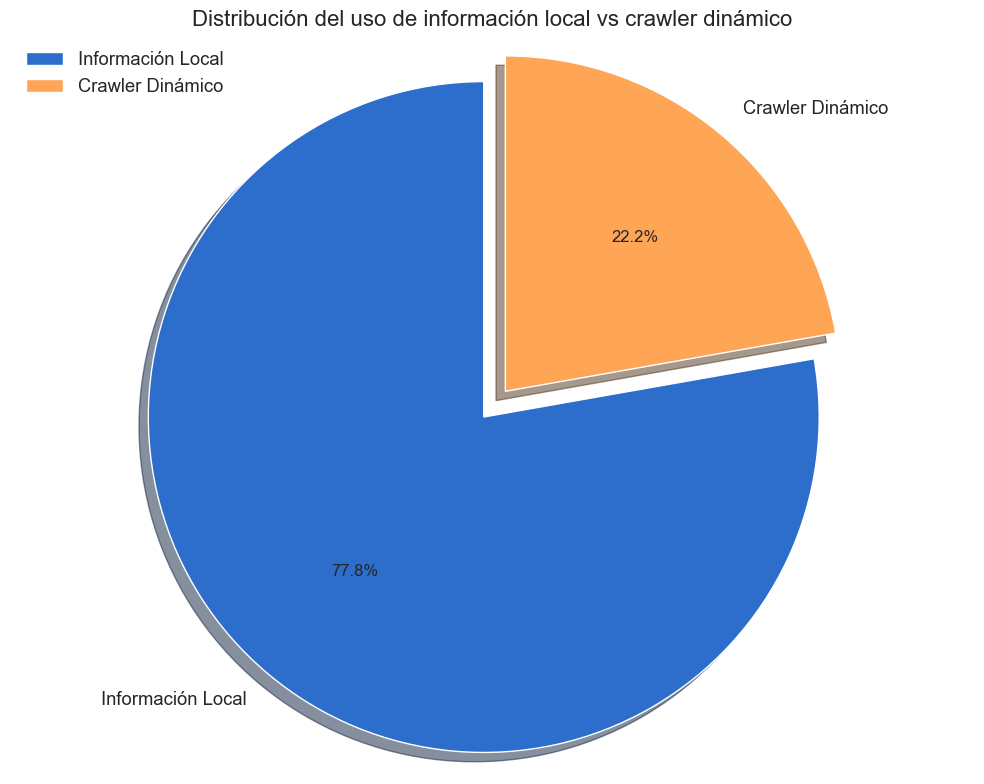

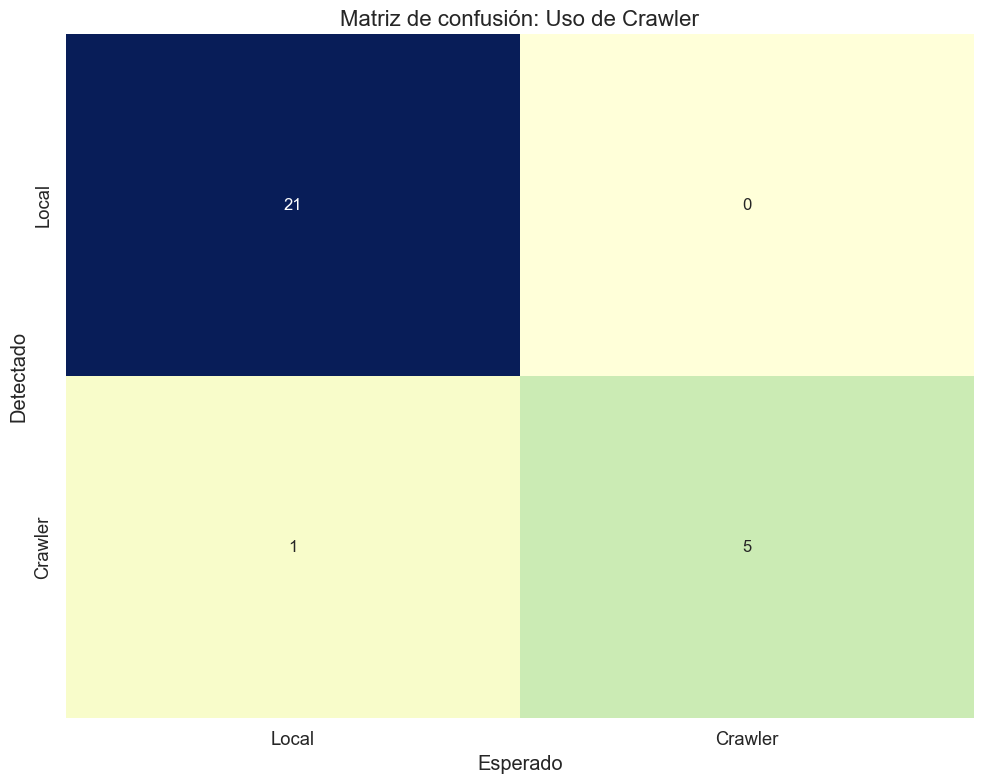

In [12]:
# Analizar uso del crawler dinámico
def analyze_crawler_usage(df):
    """Analiza qué porcentaje de consultas usan el crawler dinámico vs información local"""
    if 'detected_strategy' not in df.columns:
        print("No hay datos de estrategias detectadas")
        return None
    
    total_tests = len(df)
    
    # Contar cuántos tests usan crawler vs información local
    crawler_tests = len(df[df['detected_strategy'] == 'crawler'])
    local_tests = total_tests - crawler_tests
    
    # Calcular porcentajes
    crawler_pct = (crawler_tests / total_tests * 100) if total_tests > 0 else 0
    local_pct = (local_tests / total_tests * 100) if total_tests > 0 else 0
    
    # Analizar consultas que esperaban usar crawler pero usaron info local
    if 'expected_strategy' in df.columns:
        expected_crawler = len(df[df['expected_strategy'] == 'crawler'])
        actual_local = len(df[(df['expected_strategy'] == 'crawler') & 
                              (df['detected_strategy'] != 'crawler')])
        
        crawler_saved_pct = (actual_local / expected_crawler * 100) if expected_crawler > 0 else 0
    else:
        expected_crawler = 0
        actual_local = 0
        crawler_saved_pct = 0
    
    return {
        'total_tests': total_tests,
        'crawler_tests': crawler_tests,
        'local_tests': local_tests,
        'crawler_pct': crawler_pct,
        'local_pct': local_pct,
        'expected_crawler': expected_crawler,
        'actual_local': actual_local,
        'crawler_saved_pct': crawler_saved_pct
    }

# Analizar y visualizar uso del crawler dinámico
if not test_df.empty:
    crawler_stats = analyze_crawler_usage(test_df)
    
    if crawler_stats is not None:
        print(f"Análisis del uso del crawler dinámico:")
        print(f"- Total de tests: {crawler_stats['total_tests']}")
        print(f"- Tests que usaron crawler: {crawler_stats['crawler_tests']} ({crawler_stats['crawler_pct']:.1f}%)")
        print(f"- Tests que usaron información local: {crawler_stats['local_tests']} ({crawler_stats['local_pct']:.1f}%)")
        
        if crawler_stats['expected_crawler'] > 0:
            print(f"\nConsultas que podrían haber necesitado crawler pero se resolvieron localmente:")
            print(f"- Esperaban usar crawler: {crawler_stats['expected_crawler']}")
            print(f"- Resueltas con info local: {crawler_stats['actual_local']}")
            print(f"- Ahorro de llamadas al crawler: {crawler_stats['crawler_saved_pct']:.1f}%")
        
        # Visualizar uso del crawler dinámico con un gráfico de torta
        plt.figure(figsize=(10, 8))
        
        # Datos para el gráfico
        labels = ['Información Local', 'Crawler Dinámico']
        sizes = [crawler_stats['local_pct'], crawler_stats['crawler_pct']]
        explode = (0.1, 0)  # Destacar la porción de información local
        
        # Crear gráfico de torta
        plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
               shadow=True, startangle=90, colors=[colors[0], colors[1]])
        
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        plt.title('Distribución del uso de información local vs crawler dinámico', fontsize=16)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Si hay datos de estrategia esperada, visualizar la matriz de confusión para crawler
        if 'expected_strategy' in test_df.columns:
            # Crear una matriz simplificada de crawler/no-crawler
            df_crawler = test_df.copy()
            
            # Convertir a binario: crawler o no-crawler
            df_crawler['is_crawler_detected'] = (df_crawler['detected_strategy'] == 'crawler').astype(int)
            df_crawler['is_crawler_expected'] = (df_crawler['expected_strategy'] == 'crawler').astype(int)
            
            # Crear tabla de contingencia
            contingency = pd.crosstab(
                df_crawler['is_crawler_detected'], 
                df_crawler['is_crawler_expected'],
                rownames=['Detectado'], 
                colnames=['Esperado'],
                margins=True
            )
            
            # Reemplazar binarios por etiquetas
            contingency = contingency.rename(index={0: 'Local', 1: 'Crawler', 'All': 'Total'})
            contingency = contingency.rename(columns={0: 'Local', 1: 'Crawler', 'All': 'Total'})
            
            # Visualizar la tabla
            plt.figure(figsize=(10, 8))
            
            # Crear heatmap
            sns.heatmap(contingency.iloc[:-1, :-1], annot=True, fmt='d', cmap='YlGnBu',
                       cbar=False)
            
            plt.title('Matriz de confusión: Uso de Crawler', fontsize=16)
            plt.tight_layout()
            plt.show()
    else:
        print("No se pudieron analizar estadísticas de uso del crawler")

## 7. Conclusiones y resumen

Resumamos los principales hallazgos del análisis de los resultados de los tests:

In [13]:
# Generar resumen automático de resultados
def generate_summary(test_df, strategy_accuracy=None, response_time_stats=None, keyword_scores=None, crawler_stats=None):
    """Genera un resumen textual de los resultados del análisis"""
    summary = []
    
    if test_df.empty:
        return ["No se encontraron datos para analizar."]
    
    # Resumen general
    total_tests = len(test_df)
    summary.append(f"Se analizaron {total_tests} tests en total.")
    
    # Estrategias
    if 'detected_strategy' in test_df.columns:
        strategies = test_df['detected_strategy'].value_counts()
        summary.append("\nDistribución de estrategias detectadas:")
        
        for strategy, count in strategies.items():
            pct = count / total_tests * 100
            summary.append(f"- {strategy}: {count} tests ({pct:.1f}%)")
    
    # Precisión de estrategias
    if strategy_accuracy is not None and isinstance(strategy_accuracy, dict):
        summary.append("\nPrecisión en la selección de estrategias:")
        for strategy, stats in strategy_accuracy.items():
            pct = stats['accuracy'] * 100
            summary.append(f"- {strategy}: {pct:.1f}% ({stats['correct']}/{stats['total']} correctos)")
    
    # Tiempos de respuesta
    if response_time_stats is not None and isinstance(response_time_stats, pd.DataFrame):
        summary.append("\nTiempos de respuesta por estrategia (segundos):")
        
        for strategy, row in response_time_stats.iterrows():
            summary.append(f"- {strategy}: promedio = {row['mean']:.2f}s, mediana = {row['median']:.2f}s, "
                         f"mín = {row['min']:.2f}s, máx = {row['max']:.2f}s (n={row['count']})")
    
    # Palabras clave
    if keyword_scores is not None:
        total_expected = sum(score['total_expected'] for score in keyword_scores.values())
        total_found = sum(score['total_found'] for score in keyword_scores.values())
        overall_precision = total_found / total_expected if total_expected > 0 else 0
        
        summary.append(f"\nPresencia de palabras clave en respuestas:")
        summary.append(f"- Precisión global: {overall_precision:.2%} ({total_found}/{total_expected} palabras clave encontradas)")
    
    # Uso del crawler dinámico
    if crawler_stats is not None:
        summary.append(f"\nUso del crawler dinámico:")
        summary.append(f"- {crawler_stats['local_pct']:.1f}% de las consultas se respondieron con información local")
        summary.append(f"- {crawler_stats['crawler_pct']:.1f}% de las consultas necesitaron el crawler dinámico")
        
        if crawler_stats['expected_crawler'] > 0:
            summary.append(f"- Se evitó el uso del crawler en {crawler_stats['crawler_saved_pct']:.1f}% de los casos donde se esperaba")
    
    return summary

# Generar y mostrar resumen de resultados
if not test_df.empty:
    summary = generate_summary(test_df, strategy_accuracy, response_time_stats, keyword_scores, crawler_stats)
    
    print("="*80)
    print("RESUMEN DE RESULTADOS DEL ANÁLISIS")
    print("="*80)
    print("\n".join(summary))
    print("="*80)
else:
    print("No hay datos para generar un resumen.")

RESUMEN DE RESULTADOS DEL ANÁLISIS
Se analizaron 27 tests en total.

Distribución de estrategias detectadas:
- embedding: 11 tests (40.7%)
- ontology: 8 tests (29.6%)
- crawler: 6 tests (22.2%)

Precisión en la selección de estrategias:
- crawler: 100.0% (5/5 correctos)
- embedding: 100.0% (11/11 correctos)
- ontology: 88.9% (8/9 correctos)

Tiempos de respuesta por estrategia (segundos):
- crawler: promedio = 19.17s, mediana = 16.50s, mín = 12.00s, máx = 36.00s (n=6.0)
- embedding: promedio = 15.73s, mediana = 13.00s, mín = 12.00s, máx = 23.00s (n=11.0)
- ontology: promedio = 13.75s, mediana = 14.00s, mín = 11.00s, máx = 17.00s (n=8.0)

Presencia de palabras clave en respuestas:
- Precisión global: 58.33% (98/168 palabras clave encontradas)

Uso del crawler dinámico:
- 77.8% de las consultas se respondieron con información local
- 22.2% de las consultas necesitaron el crawler dinámico
- Se evitó el uso del crawler en 0.0% de los casos donde se esperaba


### Recomendaciones finales

Basándonos en los resultados del análisis, podemos identificar las siguientes áreas de mejora:

1. **Estrategia de selección**: Mejorar la precisión en la selección de estrategias, especialmente para consultas en la frontera entre ontología y embeddings.

2. **Tiempos de respuesta**: Optimizar los tiempos de respuesta para la estrategia que mostró mayor latencia.

3. **Cobertura de conocimiento**: Ampliar la cobertura de la ontología y mejorar la calidad de los documentos indexados para reducir la necesidad del crawler dinámico.

4. **Calidad de respuestas**: Mejorar la inclusión de palabras clave esperadas en las respuestas, especialmente para las estrategias con menor precisión.

5. **Umbrales de similitud**: Ajustar los umbrales de similitud para optimizar el balance entre precisión y uso eficiente de recursos.

Estos resultados sirven como línea base para futuras mejoras del sistema multiagente de cócteles.